# Evidencia de clase - 02/09/26

## Ruido de cuantizacion (ADC)

Se genera una senoidal contaminada con ruido analogico, se la cuantiza con un ADC de
B bits y se comparan en el dominio de la frecuencia:

- el espectro de la señal analogica ruidosa (`xxr`)
- el espectro del ruido de cuantizacion (`nq = xxq - xxr`)
- el espectro de la señal cuantizada (`xxq`)

El objetivo es ver el piso de ruido que introduce el ADC y verificar que el error de
cuantizacion se distribuye de manera uniforme entre -q/2 y +q/2, con varianza q^2/12.


In [ ]:


import numpy as np
import matplotlib.pyplot as plt

plt.close('all')


In [ ]:

fs = 1000              # frecuencia de muestreo (Hz)
N  = 1000              # cantidad de muestras
ts = 1/fs              # tiempo de muestreo
df = fs/N              # resolucion espectral (Hz)

vmax = np.sqrt(2)      # amplitud -> potencia media de la senoidal = 1 W (0 dB)
dc   = 0               # offset
ff   = 10*df           # frecuencia de la senoidal (10 bines -> sin desparramo)
ph   = 0               # fase (rad)


In [3]:
#%% ---------------- SEÑAL + RUIDO ANALOGICO --------------------

tt = np.arange(0, N/fs, ts)          # vector de tiempo
xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)    # senoidal "analogica"

# ruido analogico: lo defino como kn veces la potencia del ruido de cuantizacion
# (kn = 1 -> ambos ruidos parejos ; kn > 1 -> domina el ruido analogico)
kn = 10

pot_ruido = kn * (2*2/(2**4))**2 / 12          # q^2/12 con los datos del ADC de abajo
ruido = np.random.normal(0, np.sqrt(pot_ruido), N)

xxr = xx + ruido       # señal analogica contaminada con ruido


In [4]:
#%% -------------------------- ADC ------------------------------

B   = 4                 # Bits
Vfs = 2                 # V de referencia del ADC
qq  = 2*Vfs/(2**B)      # paso de cuantizacion (tamaño del escalon)

print("Paso de cuantizacion q = {:.4f} V".format(qq))


Paso de cuantizacion q = 0.2500 V


In [5]:
#%% ------------------ MODULO DEL ESPECTRO -----------------------

# vector de frecuencia
frec = np.arange(N//2) * fs/N

xxtr = (1/N) * np.fft.fft(xxr)             # fft normalizada de xxr
modulo_xxtr = np.abs(xxtr)
modulo_xxtr_db = 10 * np.log10( 2*(np.abs(modulo_xxtr[:N//2]) ) ** 2 )   # pone 0dB como referencia de 1W de potencia


# espectro de fase (con Ruido)
ang_tr = np.fft.fft(xxr)
fase_r = np.angle(ang_tr)/(2*np.pi)
# plt.title("Espectro Fase Con ruido")
# plt.plot(fase_r, color="gray")
# plt.show()


In [6]:
#%% ----------------------- CUANTIZACION -------------------------

xxq = np.round(xxr/qq)*qq       # señal cuantizada
nq  = xxq - xxr                 # ruido consecuencia de la cuantizacion (señal cuantizada - señal original)
nqtr = (1/N) * np.fft.fft(nq)
modulo_nqtr_db = 10 * np.log10(2*(np.abs(nqtr[:N//2]) ) ** 2)


xxqtr = (1/N) * np.fft.fft(xxq)     # tr de la señal cuantizada
modulo_xxqtr_db = 10 * np.log10(2*(np.abs(xxqtr[:N//2]) ) ** 2)   # en dB


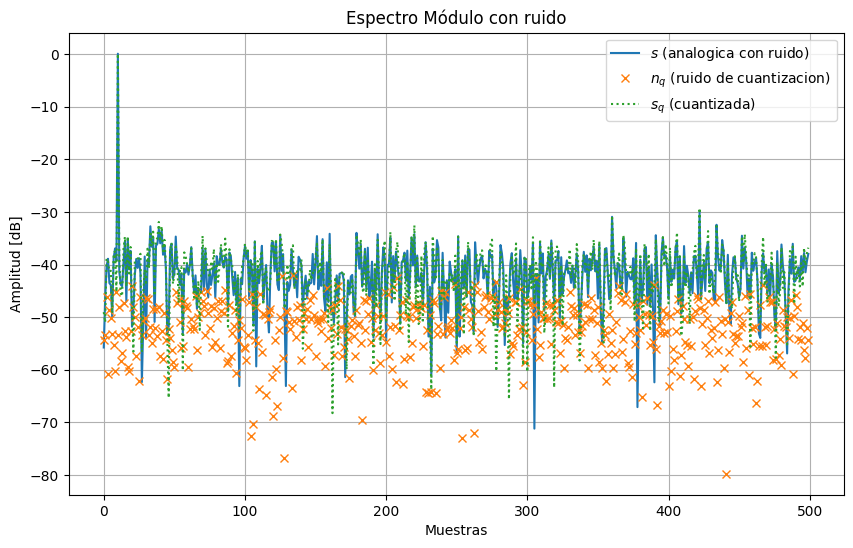

In [7]:
#%% ------------- GRAFICO DE MODULO DEL ESPECTRO -----------------

plt.figure(figsize=(10, 6))

plt.plot(frec, modulo_xxtr_db, label='$s$ (analogica con ruido)')
plt.plot(frec, modulo_nqtr_db, 'x', label='$n_q$ (ruido de cuantizacion)')
plt.plot(frec, modulo_xxqtr_db, ':', label='$s_q$ (cuantizada)')

plt.title("Espectro Módulo con ruido")
plt.ylabel("Amplitud [dB]")
plt.xlabel("Muestras")
plt.legend()
plt.grid(True)
plt.show()


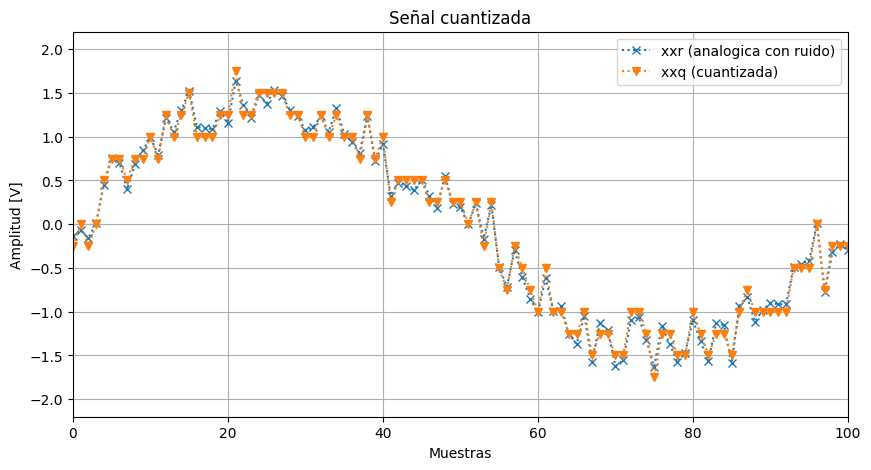

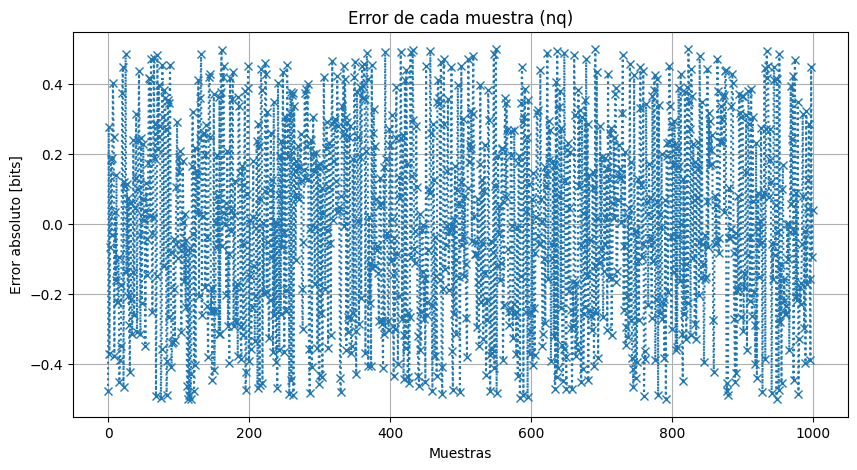

In [ ]:
#%% --------------- SEÑAL ANALOGICA VS CUANTIZADA ----------------

plt.figure(figsize=(10, 5))
plt.plot(xxr, ':x', label='xxr (analogica con ruido)')
plt.plot(xxq, ':v', label='xxq (cuantizada)')
plt.xlabel("Muestras")
plt.ylabel("Amplitud [V]")
plt.title("Señal cuantizada")
plt.xlim(0, 100)
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.title("Error de cada muestra (nq)")
plt.xlabel("Muestras")
plt.ylabel("Error absoluto [bits]")
plt.plot(nq/qq, ':x')
plt.grid(True)
plt.show()


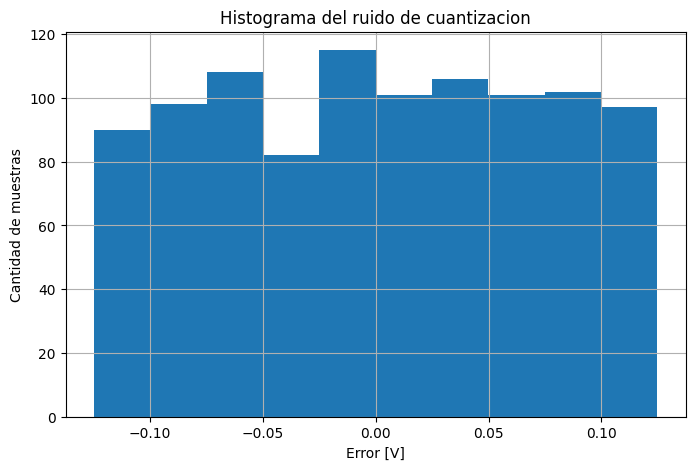

Varianza medida   : 0.005100
Varianza teorica  : 0.005208


In [9]:
#%% ------------ DISTRIBUCION DEL RUIDO DE CUANTIZACION ----------
# equivalente al "%varexp --hist nq" de Spyder

plt.figure(figsize=(8, 5))
plt.hist(nq, bins=10)
plt.title("Histograma del ruido de cuantizacion")
plt.xlabel("Error [V]")
plt.ylabel("Cantidad de muestras")
plt.grid(True)
plt.show()

print("Varianza medida   : {:.6f}".format(np.var(nq)))
print("Varianza teorica  : {:.6f}".format(qq**2/12))
